## A. Membangun Struktur Direktori HDFS

In [ ]:
!hdfs dfs -mkdir -p /user/haris/ecommerce/raw
!hdfs dfs -mkdir -p /user/haris/ecommerce/processed
!hdfs dfs -ls -R /user/haris/ecommerce

## B. Mengunggah Data Mentah Ke HDFS

In [4]:
!hdfs dfs -put transaksi_magelang.csv transaksi_yogyakarta.csv transaksi_semarang.csv /user/haris/ecommerce/raw/
!hdfs dfs -ls -h /user/haris/ecommerce/raw

Found 3 items
-rw-r--r--   1 haris supergroup     12.0 K 2026-09-10 09:00 /user/haris/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 haris supergroup     11.9 K 2026-09-10 09:00 /user/haris/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 haris supergroup     12.4 K 2026-09-10 09:00 /user/haris/ecommerce/raw/transaksi_yogyakarta.csv


## C. Membaca Kembali dan Menggabungkan Data dari HDFS


In [6]:
import subprocess
import io
import pandas as pd

def baca_csv_dari_hdfs(path_hdfs):
    hasil = subprocess.run(["hdfs", "dfs", "-cat", path_hdfs], stdout=subprocess.PIPE)
    return pd.read_csv(io.BytesIO(hasil.stdout))

df_magelang = baca_csv_dari_hdfs("/user/haris/ecommerce/raw/transaksi_magelang.csv")
df_yogyakarta = baca_csv_dari_hdfs("/user/haris/ecommerce/raw/transaksi_yogyakarta.csv")
df_semarang = baca_csv_dari_hdfs("/user/haris/ecommerce/raw/transaksi_semarang.csv")

df_gabungan = pd.concat([df_magelang, df_yogyakarta, df_semarang], ignore_index=True)
print(df_gabungan["kota"].value_counts())

kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


## D. Mengolah dan Download Hasil ke Direktori processed

In [8]:
df_gabungan["total_pendapatan"] = df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]

ringkasan_kota_kategori = (
    df_gabungan.groupby(["kota", "kategori"])["total_pendapatan"]
    .sum()
    .reset_index()
    .sort_values(["kota", "total_pendapatan"], ascending=[True, False])
)

df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan_kota_kategori.to_csv("ringkasan_kota_kategori.csv", index=False)

In [9]:
!hdfs dfs -put data_gabungan_bersih.csv ringkasan_kota_kategori.csv /user/haris/ecommerce/processed/
!hdfs dfs -ls -h /user/haris/ecommerce/processed

Found 2 items
-rw-r--r--   1 haris supergroup     40.3 K 2026-09-10 09:12 /user/haris/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 haris supergroup        530 2026-09-10 09:12 /user/haris/ecommerce/processed/ringkasan_kota_kategori.csv


## E. Dokumentasi dan Refleksi (bobot 20%)

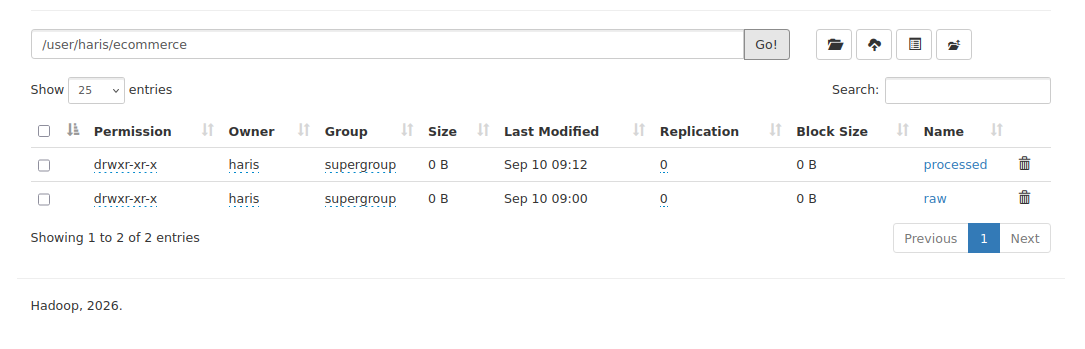

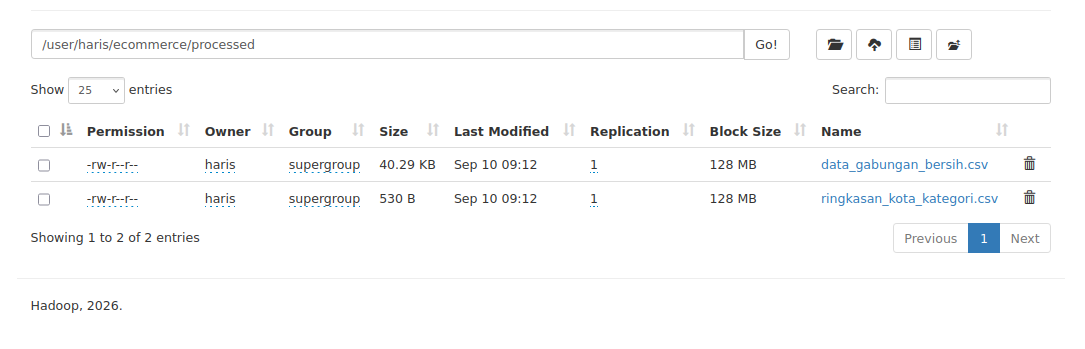

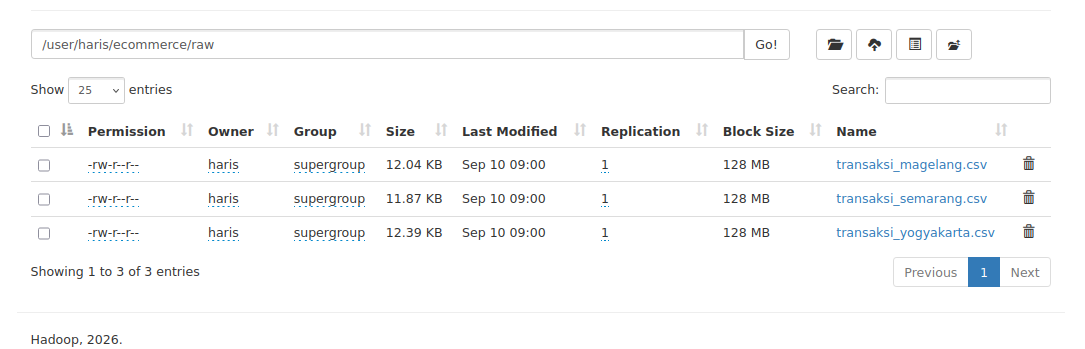

## F. Refleksi

Keuntungan pemisahan folder raw dan processed di HDFS pada dasarnya adalah implementasi arsitektur data berlapis demi menjaga reliabilitas dan efisiensi penyimpanan.  Alasan mendasarnya berpusat pada perlindungan ground truth. Berkas di direktori raw diposisikan sebagai data murni yang bersifat permanen. Jika terjadi bug pada logika agregasi atau perubahan parameter bisnis di kemudian hari, rekaman histori asli tetap aman sehingga pipeline pemrosesan ulang bisa dieksekusi tanpa risiko hilangnya data sumber.Dari sisi manajemen sistem, isolasi ini mencegah data clutter dan ambiguitas akses. Menyatukan log transaksi mentah dengan tabel hasil olahan dalam satu lokasi sangat berisiko memicu human error, seperti salah memilih berkas analisis atau menimpa dataset penting. Melalui pemisahan ini, layer konsumsi di folder processed menjadi jauh lebih rapi, siap pakai untuk analitik lanjutan, serta mempermudah audit alur data dari tahap ekstraksi hingga tahap akhir pelaporan.